# Feature Exploration and Model Summary
This notebook loads the prepared features, shows basic distributions, and visualizes model feature importances if a trained model exists.

## Prediction target
We predict whether the blue side wins the match. The target column is `blue_side_win` (binary).
The following sections show the target distribution and example feature / champion-level summaries to help reviewers understand what we're predicting.

In [1]:
# Display per-role summary CSVs (if present) for reviewers
import glob
from pathlib import Path
from IPython.display import display
per_role_files = sorted(glob.glob(str(Path('Winrate_Prediction')/ 'analysis_outputs' / '*_per_champion_stats.csv')))
dfs = []
for f in per_role_files:
    role = Path(f).name.split('_')[0]
    try:
        df_role = pd.read_csv(f)
    except Exception as e:
        print('Could not read', f, '->', e)
        continue
    name_col = next((c for c in df_role.columns if 'name' in c.lower() or 'champ' in c.lower()), None)
    games_col = next((c for c in df_role.columns if any(k in c.lower() for k in ['count','games','plays','games_played','play_count'])), None)
    win_col = next((c for c in df_role.columns if 'win' in c.lower()), None)
    if name_col is None:
        continue
    cols = [name_col]
    if games_col: cols.append(games_col)
    if win_col: cols.append(win_col)
    df2 = df_role[cols].copy()
    rename_map = {name_col: 'champion'}
    if games_col: rename_map[games_col] = 'games'
    if win_col: rename_map[win_col] = 'win_rate'
    df2 = df2.rename(columns=rename_map)
    df2['role'] = role
    dfs.append(df2)
if dfs:
    combined = pd.concat(dfs, ignore_index=True, sort=False)
    combined['champion'] = combined['champion'].astype(str)
    display(combined.sort_values(by=['role'] + ([ 'games' ] if 'games' in combined.columns else []), ascending=[True]+([False] if 'games' in combined.columns else [])).reset_index(drop=True).head(200))
else:
    print('No per-role summary CSVs found at Winrate_Prediction/analysis_outputs')

No per-role summary CSVs found at Winrate_Prediction/analysis_outputs


In [2]:
# Top champions per role (plots)
import numpy as np
if 'combined' in globals() and not combined.empty:
    roles = sorted(combined['role'].unique())
    for role in roles:
        df_r = combined[combined['role']==role].copy()
        if df_r.empty:
            continue
        if 'games' in df_r.columns:
            df_r = df_r.sort_values('games', ascending=False).head(8)
            xcol = 'games'
        else:
            df_r = df_r.sort_values('win_rate', ascending=False).head(8)
            xcol = 'win_rate'
        plt.figure(figsize=(8,4))
        sns.barplot(x=xcol, y='champion', data=df_r, palette='viridis')
        plt.title(f'Top champs for role {role}')
        if 'win_rate' in df_r.columns:
            for i, row in enumerate(df_r.itertuples()):
                val = getattr(row, xcol, np.nan)
                if xcol == 'games':
                    ann = f" win:{getattr(row, 'win_rate', np.nan):.2f}" if 'win_rate' in df_r.columns else ''
                    plt.text(val + max(1, val*0.01), i, ann, va='center')
                else:
                    ann = f" games:{int(getattr(row, 'games', 0))}" if 'games' in df_r.columns else ''
                    plt.text(val + 0.01, i, ann, va='center')
        plt.tight_layout()
        plt.show()
else:
    print('No per-role summary table available; skipping top-champion plots')

No per-role summary table available; skipping top-champion plots


In [3]:
# Summary figure: role-level average win rate and total games
if 'combined' in globals() and not combined.empty:
    # compute role summary; if 'games' present, compute games-weighted avg
    if 'games' in combined.columns and 'win_rate' in combined.columns:
        rs = combined.groupby('role').apply(lambda g: pd.Series({'avg_win_rate': (g['win_rate']*g['games']).sum()/g['games'].sum() if g['games'].sum()>0 else g['win_rate'].mean(), 'total_games': int(g['games'].sum())})).reset_index()
    elif 'win_rate' in combined.columns:
        rs = combined.groupby('role').agg(avg_win_rate=('win_rate','mean'), total_games=('win_rate','size')).reset_index()
    else:
        rs = pd.DataFrame({'role':[], 'avg_win_rate':[], 'total_games':[]})
    if not rs.empty:
        rs = rs.sort_values('avg_win_rate', ascending=False)
        fig, ax1 = plt.subplots(figsize=(8,4))
        sns.barplot(x='avg_win_rate', y='role', data=rs, ax=ax1, palette='coolwarm')
        ax1.set_xlim(0,1)
        ax1.set_xlabel('Average win rate')
        ax2 = ax1.twiny()
        ax2.plot(rs['total_games'], rs['role'].apply(lambda x: rs.index[rs['role']==x][0]), 'o-', color='black')
        ax2.set_xlabel('Total games (per-role)')
        plt.title('Role-level average win rate and total games')
        plt.tight_layout()
        plt.show()
    else:
        print('Role summary could not be computed (missing columns).')
else:
    print('No per-role summary table available; skipping summary figure')

No per-role summary table available; skipping summary figure


In [4]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
FEATURES_PATH = Path('../data/processed/features.parquet')
# Model path (repo root models directory)
MODEL_PATH = Path('../../models/xgb_patch_model.pkl')
if not MODEL_PATH.exists():
    print('Model not found at', MODEL_PATH, '; expected at repo root models/xgb_patch_model.pkl')
else:
    print('Using model at', MODEL_PATH)
if not FEATURES_PATH.exists():
    print('Features file not found at', FEATURES_PATH, '- skipping loading and visualizations.')
    df = pd.DataFrame()
else:
    df = pd.read_parquet(FEATURES_PATH)
    print('Loaded features:', df.shape)
    df.head()

Model not found at ..\..\models\xgb_patch_model.pkl ; expected at repo root models/xgb_patch_model.pkl
Features file not found at ..\data\processed\features.parquet - skipping loading and visualizations.


In [5]:
# Target distribution
if 'df' in globals() and not df.empty:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(x='blue_side_win', data=df)
    ax.set_title('Target distribution (blue_side_win)')
    plt.show()
    # Summary stats
    display(df['blue_side_win'].describe())
else:
    print('No features loaded; skipping target distribution plot.')

No features loaded; skipping target distribution plot.


In [6]:
# Win rate by patch (top 20 patches by count)
if 'df' in globals() and not df.empty:
    if 'patch_version' in df.columns:
        pv = df.groupby('patch_version').agg(n=('blue_side_win','size'), winrate=('blue_side_win','mean')).reset_index()
        pv_sorted = pv.sort_values('n', ascending=False).head(20)
        plt.figure(figsize=(12,5))
        sns.barplot(y='patch_version', x='winrate', data=pv_sorted, palette='viridis')
        plt.xlabel('Blue side win rate')
        plt.ylabel('Patch (top 20 by count)')
        plt.title('Blue side win rate by patch (top 20)')
        plt.xlim(0,1)
        plt.show()
    else:
        print('No patch_version column found in features.')
else:
    print('No features loaded; skipping patch-level winrate plot.')

No features loaded; skipping patch-level winrate plot.


In [7]:
# Show some example numeric summaries
if 'df' in globals() and not df.empty:
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    print('Numeric columns:', len(num_cols))
    display(df[num_cols].describe().T)
else:
    print('No features loaded; skipping numeric summaries')


No features loaded; skipping numeric summaries


Using raw matches at C:\Users\Student\OneDrive - Birmingham City University\2nd Year\MLOPS\Assignment\data\raw\matches.parquet


,champ_id,champ_name,side,position,count,winrate
250,103,Ahri,blue,ADC,115,0.469565
264,134,Syndra,blue,ADC,95,0.526316
291,517,Sylas,blue,ADC,93,0.462366
229,61,Orianna,blue,ADC,79,0.443038
270,157,Yasuo,blue,ADC,71,0.450704
241,84,Akali,blue,ADC,70,0.457143
226,55,Katarina,blue,ADC,62,0.612903
279,238,Zed,blue,ADC,62,0.370968
254,112,Viktor,blue,ADC,59,0.610169
300,893,Aurora,blue,ADC,58,0.448276


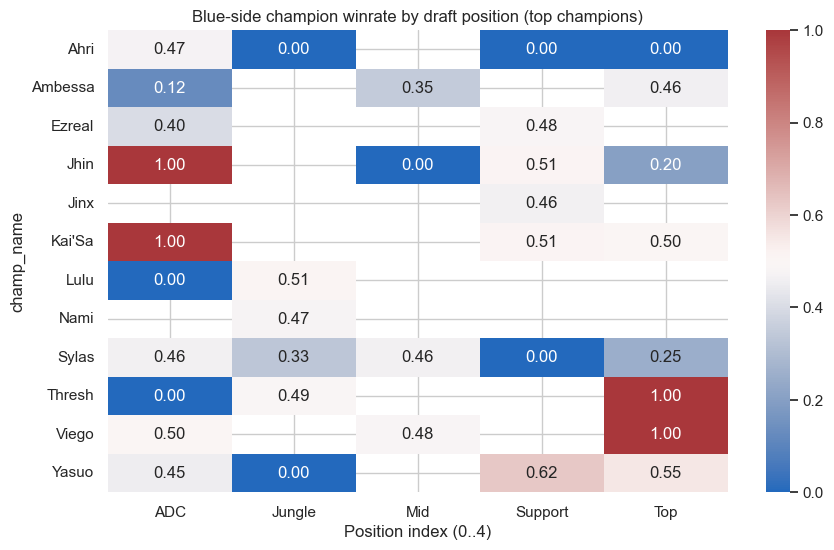

In [8]:
# Analyze champion performance by position (blue_0..blue_4, red_0..red_4)
from pathlib import Path
import sys
# Ensure the repo root (parent of this Winrate_Prediction package) is on sys.path
sys.path.insert(0, str(Path('..').resolve()))
import json
import pandas as pd
import importlib.util
# Load feature_engineering.py by path to avoid package import issues
fe_path = Path('../src/feature_engineering.py').resolve()
spec = importlib.util.spec_from_file_location('feature_engineering', fe_path)
fe = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fe)
build_dataframe_from_matches = fe.build_dataframe_from_matches
# Locate raw matches file by searching upward from current working directory
raw_path = None
cur = Path('.').resolve()
for _ in range(6):
    candidate = cur / 'data' / 'raw' / 'matches.parquet'
    if candidate.exists():
        raw_path = candidate
        break
    cur = cur.parent
if raw_path is None:
    print('Raw matches file not found (searched upward).')
else:
    print('Using raw matches at', raw_path)
    raw_df = pd.read_parquet(raw_path)
    match_jsons = [json.loads(x) if isinstance(x, str) else x for x in raw_df['match_json'].tolist()]
    pos_df = build_dataframe_from_matches(match_jsons)
    # build mapping id->name (try DataDragon, fallback to id)
    id_to_name = {}
    # map numeric draft positions to lane names
    pos_map = {0: 'Top', 1: 'Mid', 2: 'ADC', 3: 'Support', 4: 'Jungle'}
    try:
        import requests
        ver = requests.get('https://ddragon.leagueoflegends.com/api/versions.json').json()[0]
        cj = requests.get(f'https://ddragon.leagueoflegends.com/cdn/{ver}/data/en_US/champion.json').json()
        id_to_name = {int(v['key']): v['name'] for v in cj['data'].values()}
    except Exception as _e:
        print('Could not fetch champion mapping:', _e)
    records = []
    for side in ['blue', 'red']:
        for pos in range(5):
            col = f'{side}_{pos}'
            if col not in pos_df.columns:
                continue
            grp = pos_df[[col, 'blue_side_win']].dropna(subset=[col])
            if grp.empty:
                continue
            stats = grp.groupby(col)['blue_side_win'].agg(['size','mean']).reset_index().rename(columns={'size':'count','mean':'winrate'})
            stats['side'] = side
            stats['position'] = pos
            for _, r in stats.iterrows():
                cid = int(r[col])
                records.append({'champ_id': cid, 'champ_name': id_to_name.get(cid, str(cid)), 'side': side, 'position': pos_map.get(pos, pos), 'count': int(r['count']), 'winrate': float(r['winrate'])})
    pos_stats = pd.DataFrame.from_records(records)
    display(pos_stats.sort_values(['side','position','count'], ascending=[True,True,False]).head(40))
    # plot heatmap of top champions by position (example for blue side)
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10,6))
    # pivot to positions x champ (limit to top 12 by overall count)
    top_champs = pos_stats.groupby('champ_name')['count'].sum().nlargest(12).index.tolist()
    pivot = pos_stats[pos_stats['champ_name'].isin(top_champs) & (pos_stats['side']=='blue')].pivot(index='champ_name', columns='position', values='winrate')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='vlag', vmin=0, vmax=1)
    plt.title('Blue-side champion winrate by draft position (top champions)')
    plt.xlabel('Position index (0..4)')
    plt.show()

In [9]:
# If a model exists, load and show feature importances
import pickle
import numpy as np
import re
if 'df' in globals() and not df.empty and MODEL_PATH.exists():
    try:
        with open(MODEL_PATH, 'rb') as fh:
            model = pickle.load(fh)
        # try sklearn-style importances first
        if hasattr(model, 'feature_importances_'):
            fi = model.feature_importances_
            feat_names = df.drop(columns=['blue_side_win','patch_version'], errors='ignore').columns.tolist()
            imp = pd.Series(fi, index=feat_names).sort_values(ascending=False).head(30)
        else:
            # try booster get_score
            booster = getattr(model, 'get_booster', lambda: None)()
            if booster is not None:
                scores = booster.get_score(importance_type='gain')
                imp = pd.Series(scores).sort_values(ascending=False).head(30)
            else:
                imp = None
        # Attempt to fetch champion id -> name mapping from Data Dragon
        id_to_name = {}
        try:
            import requests
            ver = requests.get('https://ddragon.leagueoflegends.com/api/versions.json').json()[0]
            cj = requests.get(f'https://ddragon.leagueoflegends.com/cdn/{ver}/data/en_US/champion.json').json()
            id_to_name = {int(v['key']): v['name'] for v in cj['data'].values()}
        except Exception as _e:
            # offline-friendly: keep empty mapping and continue
            print('Could not fetch champion mapping:', _e)
            id_to_name = {}
        def label_champ(col):
            m = re.search(r'_(\d+)$', col)
            if m:
                cid = int(m.group(1))
                name = id_to_name.get(cid)
                if name:
                    return col.rsplit('_',1)[0] + '_' + name
            return col
        if imp is not None and not imp.empty:
            # rename champion id suffixes to champion names when possible
            imp.index = [label_champ(c) for c in imp.index]
            plt.figure(figsize=(8,10))
            sns.barplot(x=imp.values, y=imp.index, palette='magma')
            plt.title('Top feature importances')
            plt.xlabel('Importance')
            plt.show()
        else:
            print('No feature importances available from the model.')
    except Exception as e:
        print('Failed to load model:', e)
else:
    print('Skipping model feature importances (no model file or no features loaded).')


Skipping model feature importances (no model file or no features loaded).


In [10]:
# Fetch matches from puuids using the fetch_from_puuids script
# Equivalent shell command:
# python -m Winrate_Prediction.src.fetch_from_puuids --puuid-file ../puuids.txt --target 10000
import subprocess
subprocess.run([
    "python", "-m", "Winrate_Prediction.src.fetch_from_puuids",
    "--puuid-file", "../puuids.txt",
    "--target", "10000"
])

CompletedProcess(args=['python', '-m', 'Winrate_Prediction.src.fetch_from_puuids', '--puuid-file', '../puuids.txt', '--target', '10000'], returncode=1)